# Ejemplo aplicado: regresión lineal — California Housing

Misma plantilla que [01-regresion-lineal.ipynb](01-regresion-lineal.ipynb), ya configurada para `california_housing.csv` (target `MedHouseVal`, separador `,`).

> Para un CSV nuevo, parte de la **plantilla genérica** `01-regresion-lineal.ipynb`, no de este archivo.


In [1]:
# --- Imports: librerías usadas en todo el notebook ---
import importlib  # Cargar XGBoost/CatBoost solo si están instalados
import warnings

import matplotlib.pyplot as plt  # Gráficos (EDA, comparación de modelos)
import numpy as np
import pandas as pd  # Carga y exploración del CSV
import seaborn as sns
from sklearn.compose import ColumnTransformer  # Preprocesado distinto por tipo de columna
from sklearn.impute import SimpleImputer  # Rellenar valores faltantes (NaN)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline  # Encadena pasos: preprocess → modelo
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")


def infer_feature_columns(df, target_col, drop_cols, feature_cols):
    """Devuelve la lista de columnas que entrarán como X (features).

    Si FEATURE_COLS está definido en CONFIG, usa esa lista.
    Si no, toma todas las columnas excepto el target y DROP_COLS (ids, leakage, etc.).
    """
    if feature_cols is not None:
        return list(feature_cols)
    exclude = {target_col, *drop_cols}
    return [c for c in df.columns if c not in exclude]


def infer_column_types(X, numeric_cols=None, categorical_cols=None):
    """Separa columnas numéricas y categóricas para el ColumnTransformer.

    Por defecto: int/float → numéricas; object/category/bool → categóricas.
    Puedes forzar listas en CONFIG (NUMERIC_COLS / CATEGORICAL_COLS) si pandas
    no detecta bien el tipo (p. ej. códigos postales guardados como número).
    """
    if numeric_cols is None:
        numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    if categorical_cols is None:
        categorical_cols = X.select_dtypes(
            include=["object", "category", "bool"]
        ).columns.tolist()
    return list(numeric_cols), list(categorical_cols)


def build_preprocess(numeric_cols, categorical_cols):
    """Construye el preprocesador compartido por TODOS los modelos del benchmark.

    - Numéricas: imputar → escalar.
    - Categóricas: imputar → codificar.

    El fit solo se hace en train (dentro de pipe.fit); en test solo transform,
    para no filtrar información del conjunto de evaluación (data leakage).
    """
    transformers = []

    # --- Rama numérica ---
    if numeric_cols:
        transformers.append(
            (
                "num",
                Pipeline(
                    [
                        # Imputer: rellena NaN. Alternativas de strategy:
                        #   "mean", "median" (robusto a outliers), "most_frequent", constant
                        ("imputer", SimpleImputer(strategy="median")),
                        # Escalado: media 0, std 1. Alternativas:
                        #   MinMaxScaler (rango [0,1]), RobustScaler (outliers),
                        #   Normalizer (por fila). Sin escalar: quitar este paso.
                        ("scaler", StandardScaler()),
                    ]
                ),
                numeric_cols,
            )
        )

    # --- Rama categórica ---
    if categorical_cols:
        transformers.append(
            (
                "cat",
                Pipeline(
                    [
                        # Moda para categóricas faltantes
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        (
                            "encoder",
                            # One-hot: una columna binaria por categoría.
                            # Alternativas:
                            #   OrdinalEncoder — orden fijo (talla S,M,L); ahorra columnas
                            #   TargetEncoder — media del target por categoría (cuidado leakage;
                            #                   usar solo dentro del Pipeline en train)
                            # handle_unknown="ignore": en test, categorías nuevas → ceros
                            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                        ),
                    ]
                ),
                categorical_cols,
            )
        )

    if not transformers:
        raise ValueError("No hay columnas numéricas ni categóricas para preprocesar.")
    # remainder="drop": columnas no listadas se descartan (no entran al modelo)
    return ColumnTransformer(transformers, remainder="drop")


def _optional_estimator(module_name, class_name, **kwargs):
    """Crea un estimador (p. ej. XGBRegressor) solo si el paquete está instalado.

    Si falta xgboost o catboost, devuelve None y el benchmark sigue con el resto.
    """
    try:
        module = importlib.import_module(module_name)
        cls = getattr(module, class_name)
        return cls(**kwargs)
    except ImportError:
        print(f"  [aviso] {module_name}.{class_name} no instalado (pip install {module_name})")
        return None


## 1. Explorar el CSV (antes de CONFIG)

Ejecuta esta celda con un CSV nuevo **solo** para ver columnas, tipos y faltantes. Con eso rellenas `TARGET_COL`, `DROP_COLS`, etc. en la celda siguiente.

Si el `head()` se ve mal (todo en una columna), cambia `PREVIEW_SEP` a `","`, `";"` o `"\t"`.

In [2]:
# Ruta y separador del CSV (único ajuste antes de ver la tabla)
PREVIEW_PATH = "data/california_housing.csv"
PREVIEW_SEP = ","  # Prueba: ","  |  ";"  |  "\t"

df_preview = pd.read_csv(PREVIEW_PATH, sep=PREVIEW_SEP)

print(f"Filas: {len(df_preview):,}  |  Columnas: {len(df_preview.columns)}")
print("\n--- Nombres de columnas (índice : nombre) ---")
for i, col in enumerate(df_preview.columns):
    print(f"  {i:2d}: {col!r}")

print("\n--- Tipos de datos (dtypes) ---")
print(df_preview.dtypes)

print("\n--- Primeras filas ---")
display(df_preview.head())

print("\n--- Valores faltantes por columna ---")
missing = df_preview.isna().sum()
if missing.any():
    display(missing[missing > 0].to_frame("nulos"))
else:
    print("No hay valores faltantes.")

# Sugerencia para NUMERIC_COLS / CATEGORICAL_COLS en CONFIG (si dejas None, se infieren igual)
_num = df_preview.select_dtypes(include=[np.number]).columns.tolist()
_cat = df_preview.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
print("\n--- Sugerencia automática de tipos ---")
print("Numéricas (int/float):", _num)
print("Categóricas (object/category/bool):", _cat)

print(
    "\n>>> Siguiente paso: en CONFIG usa el mismo PREVIEW_PATH → DATA_PATH, "
    "PREVIEW_SEP → CSV_SEP, y elige TARGET_COL (columna numérica a predecir)."
)

Filas: 20,640  |  Columnas: 9

--- Nombres de columnas (índice : nombre) ---
   0: 'MedInc'
   1: 'HouseAge'
   2: 'AveRooms'
   3: 'AveBedrms'
   4: 'Population'
   5: 'AveOccup'
   6: 'Latitude'
   7: 'Longitude'
   8: 'MedHouseVal'

--- Tipos de datos (dtypes) ---
MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object

--- Primeras filas ---


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422



--- Valores faltantes por columna ---
No hay valores faltantes.

--- Sugerencia automática de tipos ---
Numéricas (int/float): ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']
Categóricas (object/category/bool): []

>>> Siguiente paso: en CONFIG usa el mismo PREVIEW_PATH → DATA_PATH, PREVIEW_SEP → CSV_SEP, y elige TARGET_COL (columna numérica a predecir).


## 2. CONFIG

In [3]:
# ========== CONFIG (editar al cambiar de dataset) ==========
# Mismos valores que PREVIEW_PATH y PREVIEW_SEP en la celda de exploración
DATA_PATH = "data/california_housing.csv"
# Ejemplo otro archivo: DATA_PATH = "data/wine_quality_red.csv"

CSV_SEP = ","
# Ejemplos: "," (estándar)  |  ";" (wine quality)  |  "\t" (TSV)

# Columna que quieres PREDECIR (precio mediano de la vivienda, en cientos de miles $)
TARGET_COL = "MedHouseVal"
# Ejemplos: "quality" (wine), "mpg", "precio"

# Columnas que NO deben usarse como features (ids, texto libre, duplicados del target)
DROP_COLS = []
# Ejemplos: ["id", "id_vivienda"]  |  ["PassengerId", "Name"] (Titanic, si el target es Survived)

# Si None: todas las columnas salvo TARGET_COL y DROP_COLS
FEATURE_COLS = None
# Ejemplo manual: FEATURE_COLS = ["MedInc", "HouseAge", "AveRooms"]

# Si None: se infieren por tipo (int/float vs object/category)
NUMERIC_COLS = None
# Ejemplo: NUMERIC_COLS = ["edad", "ingresos", "hijos"]

CATEGORICAL_COLS = None
# Ejemplo: CATEGORICAL_COLS = ["ciudad", "tipo_contrato", "color"]

# Fracción para test (0.2 = 20 % test, 80 % train)
TEST_SIZE = 0.2

# Semilla para reproducir el mismo split y modelos aleatorios
RANDOM_STATE = 42

# Métrica para ordenar la tabla de comparación (mayor R² = mejor en regresión)
METRIC_PRINCIPAL = "r2"


def build_models():
    """Diccionario nombre → estimador. Comenta líneas para excluir modelos del benchmark."""
    from sklearn.ensemble import (
        GradientBoostingRegressor,
        HistGradientBoostingRegressor,
        RandomForestRegressor,
    )
    from sklearn.linear_model import Lasso, LinearRegression, Ridge

    models = {
        # Baseline lineales (rápidos). Alternativas: ElasticNet, BayesianRidge
        "LinearRegression": LinearRegression(),
        "Ridge": Ridge(random_state=RANDOM_STATE),
        "Lasso": Lasso(random_state=RANDOM_STATE, max_iter=5000),
        # No lineales. n_estimators=100 equilibra velocidad y calidad en demos
        "RandomForest": RandomForestRegressor(
            n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1
        ),
        "GradientBoosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
        "HistGradientBoosting": HistGradientBoostingRegressor(random_state=RANDOM_STATE),
    }
    # Requieren: pip install xgboost / catboost
    xgb = _optional_estimator(
        "xgboost", "XGBRegressor",
        random_state=RANDOM_STATE, verbosity=0, n_estimators=100, n_jobs=-1,
    )
    if xgb is not None:
        models["XGBoost"] = xgb
    cat = _optional_estimator(
        "catboost", "CatBoostRegressor",
        random_state=RANDOM_STATE, verbose=False, iterations=100,
        allow_writing_files=False,  # no crea carpeta catboost_info/
    )
    if cat is not None:
        models["CatBoost"] = cat
    return models


MODELS = build_models()



## 3. Carga de datos

In [4]:
df = pd.read_csv(DATA_PATH, sep=CSV_SEP)
print("Shape:", df.shape)
df.head()

Shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 4. Calidad de datos

In [5]:
print(df.info())
print("\nFaltantes por columna:")
missing = df.isna().sum()
print(missing[missing > 0] if missing.any() else "Sin valores faltantes")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None

Faltantes por columna:
Sin valores faltantes


## 5. Visualización rápida

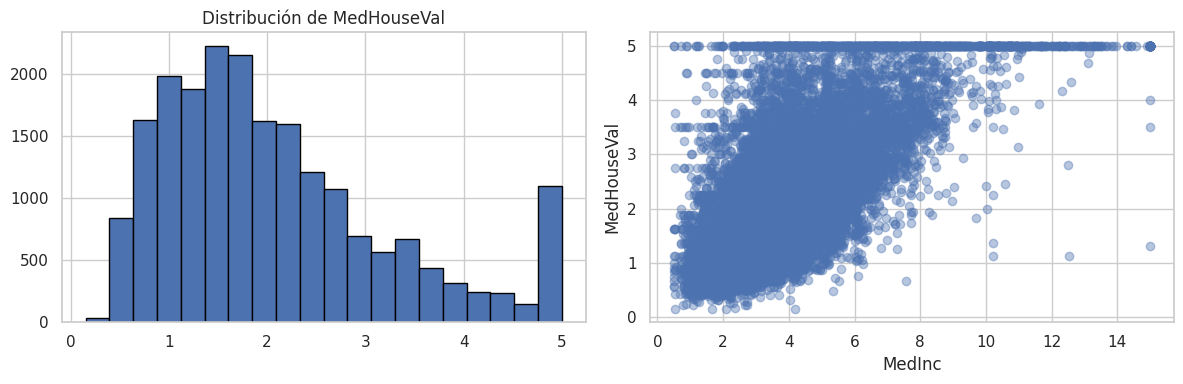

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df[TARGET_COL].hist(ax=axes[0], bins=20, edgecolor="black")
axes[0].set_title(f"Distribución de {TARGET_COL}")
num_feat = df.select_dtypes(include=[np.number]).columns.drop(TARGET_COL, errors="ignore")
if len(num_feat):
    feat = num_feat[0]
    axes[1].scatter(df[feat], df[TARGET_COL], alpha=0.4)
    axes[1].set_xlabel(feat)
    axes[1].set_ylabel(TARGET_COL)
plt.tight_layout()
plt.show()

## 6. Separar X / y y split train-test

In [7]:
feature_cols = infer_feature_columns(df, TARGET_COL, DROP_COLS, FEATURE_COLS)
X = df[feature_cols]
y = df[TARGET_COL]
numeric_cols, categorical_cols = infer_column_types(X, NUMERIC_COLS, CATEGORICAL_COLS)
print("Numéricas:", numeric_cols)
print("Categóricas:", categorical_cols)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

Numéricas: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Categóricas: []


## 7. Preprocesado (compartido por todos los modelos)

In [8]:
preprocess = build_preprocess(numeric_cols, categorical_cols)
preprocess

,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


## 8. Comparar modelos

,modelo,mae,rmse,r2
5,HistGradientBoosting,0.3096,0.4642,0.8355
7,CatBoost,0.3143,0.4665,0.8339
6,XGBoost,0.3096,0.4718,0.8301
3,RandomForest,0.3274,0.5051,0.8053
4,GradientBoosting,0.3717,0.5422,0.7756
1,Ridge,0.5332,0.7456,0.5758
0,LinearRegression,0.5332,0.7456,0.5758
2,Lasso,0.9061,1.1449,-0.0002


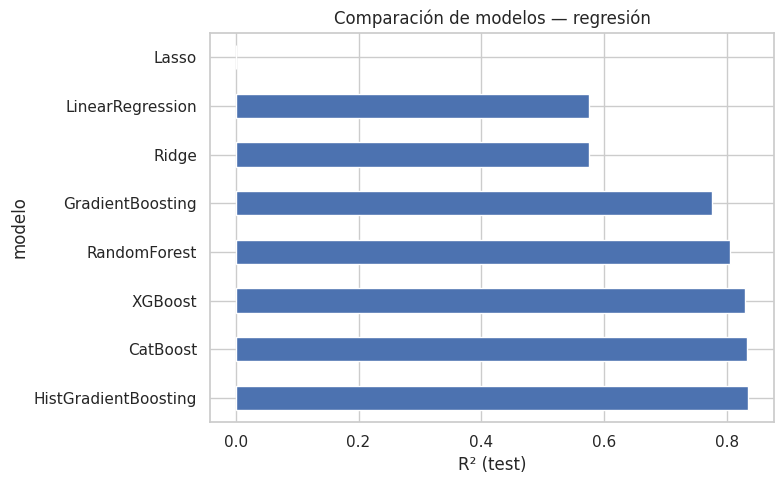

In [9]:
def regression_metrics(y_true, y_pred):
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)
    return {"mae": mae, "rmse": rmse, "r2": r2}


def evaluate_models(models, preprocess, X_train, X_test, y_train, y_test):
    rows = []
    for name, estimator in models.items():
        pipe = Pipeline([("preprocess", preprocess), ("model", estimator)])
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)
        rows.append({"modelo": name, **regression_metrics(y_test, y_pred)})
    return pd.DataFrame(rows).sort_values(METRIC_PRINCIPAL, ascending=False)

results = evaluate_models(MODELS, preprocess, X_train, X_test, y_train, y_test)
display(results.round(4))

ax = results.plot(x="modelo", y=METRIC_PRINCIPAL, kind="barh", legend=False, figsize=(8, 5))
ax.set_xlabel("R² (test)")
ax.set_title("Comparación de modelos — regresión")
plt.tight_layout()
plt.show()


## 9. Detalle del mejor modelo

Mejor modelo (test): HistGradientBoosting


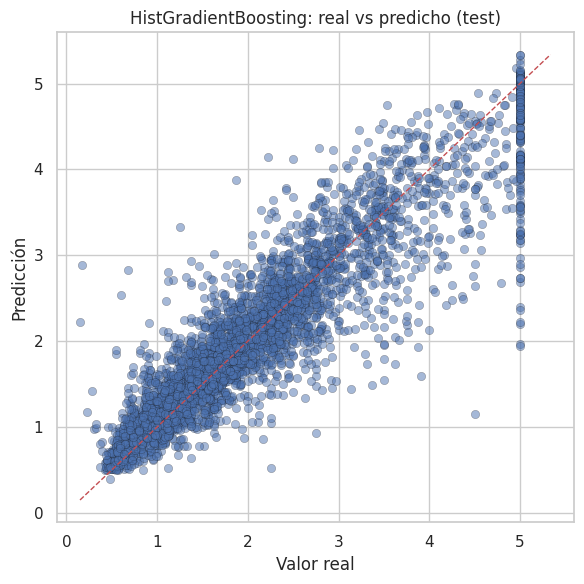

In [10]:
best_name = results.iloc[0]["modelo"]
print(f"Mejor modelo (test): {best_name}")

best_est = MODELS[best_name]
best_pipe = Pipeline([("preprocess", preprocess), ("model", best_est)])
best_pipe.fit(X_train, y_train)
y_pred_best = best_pipe.predict(X_test)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred_best, alpha=0.5, edgecolors="k", linewidths=0.3)
lims = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
ax.plot(lims, lims, "r--", lw=1)
ax.set_xlabel("Valor real")
ax.set_ylabel("Predicción")
ax.set_title(f"{best_name}: real vs predicho (test)")
plt.tight_layout()
plt.show()


## Checklist: nuevo dataset

1. Coloca el CSV en `data/` y actualiza `DATA_PATH`, `TARGET_COL` y `DROP_COLS`.
2. Revisa faltantes y `dtypes` (celdas de EDA).
3. Ajusta `NUMERIC_COLS` / `CATEGORICAL_COLS` si la detección automática falla.
4. En clasificación, comprueba el balance de clases.
5. Opcional: edita `build_models()` para añadir o quitar algoritmos.
6. Ejecuta todas las celdas y compara la tabla de resultados.
